# YOLOv11 – Detecção de Head / Helmet / Vest

Notebook para treinar um modelo YOLOv11 no dataset **Hardhat Vest Dataset v3** usando o caminho local baixado via `kagglehub`.

In [42]:
# Célula 1 - Instalar dependências (se necessário) e baixar dataset

try:
    import kagglehub  # já instalado
except ImportError:
    %pip install kagglehub

from pathlib import Path

# Baixa (ou usa cache local) do dataset
data_path_str = kagglehub.dataset_download("muhammetzahitaydn/hardhat-vest-dataset-v3")
DATA_ROOT = Path(data_path_str)

print("Dataset baixado em:", DATA_ROOT)
print("Conteúdo:", list(DATA_ROOT.iterdir()))

Dataset baixado em: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2
Conteúdo: [WindowsPath('C:/Users/Pedro/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/images'), WindowsPath('C:/Users/Pedro/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/labels')]


In [43]:
# Célula 2 - Conferir estrutura de pastas (images/labels + splits)
from pathlib import Path
import os

IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

print("IMAGES_DIR:", IMAGES_DIR)
print("LABELS_DIR:", LABELS_DIR)

for split in ["train", "val", "test"]:
    img_split = IMAGES_DIR / split
    lbl_split = LABELS_DIR / split
    print(f"\nSplit: {split}")
    print("  Imagens:", len(list(img_split.glob('*.jpg'))))
    print("  Labels :", len(list(lbl_split.glob('*.txt'))))

IMAGES_DIR: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images
LABELS_DIR: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\labels

Split: train
  Imagens: 15005
  Labels : 17248

Split: val
  Imagens: 1965
  Labels : 2438

Split: test
  Imagens: 1980
  Labels : 2455


In [44]:
# Célula 3 - Criar arquivo YAML para o YOLO (hardhat.yaml)
import textwrap

yaml_path = Path("hardhat.yaml")

# O Ultralytics interpreta `path` como diretório base onde existem as pastas images/ e labels/
yaml_content = f"""
path: {DATA_ROOT.as_posix()}
train: images/train
val: images/val
test: images/test

nc: 3
names: [Helmet, Vest, Head]
""".strip() + "\n"

yaml_path.write_text(yaml_content, encoding="utf-8")
print("YAML salvo em:", yaml_path.resolve())
print("\nConteúdo do hardhat.yaml:\n")
print(yaml_content)

YAML salvo em: C:\Users\Pedro\Documents\FACULDADE\8Semestre\visao_computacional\proj_final\ProjetoFinalVC\hardhat.yaml

Conteúdo do hardhat.yaml:

path: C:/Users/Pedro/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2
train: images/train
val: images/val
test: images/test

nc: 3
names: [Helmet, Vest, Head]



In [45]:
# Célula 4 - Instalar ultralytics (se necessário) e configurar device
try:
    from ultralytics import YOLO
except ImportError:
    %pip install ultralytics
    from ultralytics import YOLO

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device em uso:", device)

Device em uso: cuda


In [46]:
# Célula 5 - Treinar o modelo YOLOv11 no dataset de capacete/coleto

# Carrega um modelo base pré-treinado (yolo11n = versão pequena, mais rápida)
model = YOLO("yolo11n.pt")  # você pode trocar por yolo11s.pt para melhor acurácia

results = model.train(
    data="hardhat.yaml",   # nosso YAML
    epochs=1,              # ajuste conforme tempo disponível
    imgsz=640,              # resolução de entrada
    device=0 if device == "cuda" else "cpu",  # usa GPU se disponível
    batch=16,               # depende da sua VRAM; ajuste se necessário
)

print("Treino concluído.")

New https://pypi.org/project/ultralytics/8.3.231 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.230  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=hardhat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train9, nbs=64, nms=False, opset=None, op

In [49]:
# Célula 6 - Visualizar resultados de treino (loss, mAP, etc.)
import matplotlib.pyplot as plt
from pathlib import Path

# O Ultralytics salva os gráficos em runs/detect/train*/results.png
runs_dir = Path("runs/detect")
if runs_dir.exists():
    subdirs = sorted([d for d in runs_dir.iterdir() if d.is_dir()])
    if subdirs:
        last_run = subdirs[-1]
        results_png = last_run / "results.png"
        print("Último experimento:", last_run)
        if results_png.exists():
            from IPython.display import display
            display(plt.imread(results_png))
        else:
            print("results.png não encontrado em", last_run)
    else:
        print("Nenhuma pasta de treino encontrada em runs/detect.")
else:
    print("Diretório runs/detect não existe ainda (treino não foi executado?).")

Último experimento: runs\detect\train9


array([[[          1,           1,           1,           1],
        [          1,           1,           1,           1],
        [          1,           1,           1,           1],
        ...,
        [          1,           1,           1,           1],
        [          1,           1,           1,           1],
        [          1,           1,           1,           1]],

       [[          1,           1,           1,           1],
        [          1,           1,           1,           1],
        [          1,           1,           1,           1],
        ...,
        [          1,           1,           1,           1],
        [          1,           1,           1,           1],
        [          1,           1,           1,           1]],

       [[          1,           1,           1,           1],
        [          1,           1,           1,           1],
        [          1,           1,           1,           1],
        ...,
        [          1,      

Total de imagens de teste: 1980

Imagem: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\a03398.jpg



image 1/1 C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\a03398.jpg: 640x640 1 Helmet, 8.9ms
Speed: 1.3ms preprocess, 8.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


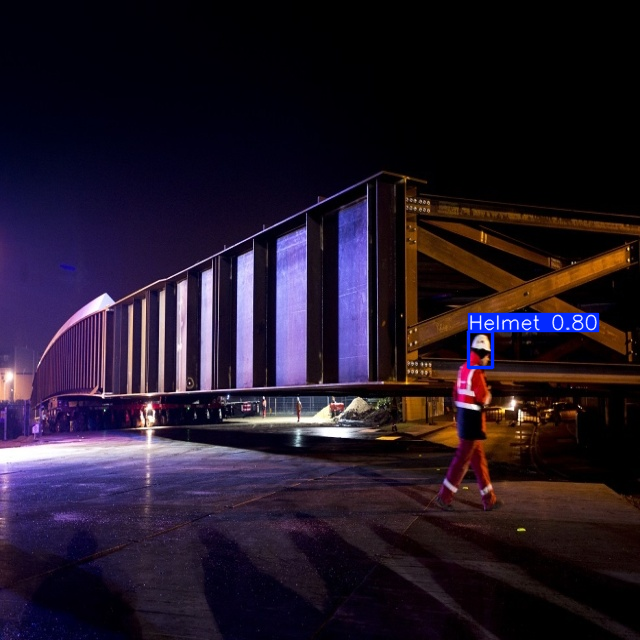


Imagem: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\002888.jpg

image 1/1 C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\002888.jpg: 640x640 1 Helmet, 7.4ms
Speed: 1.0ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


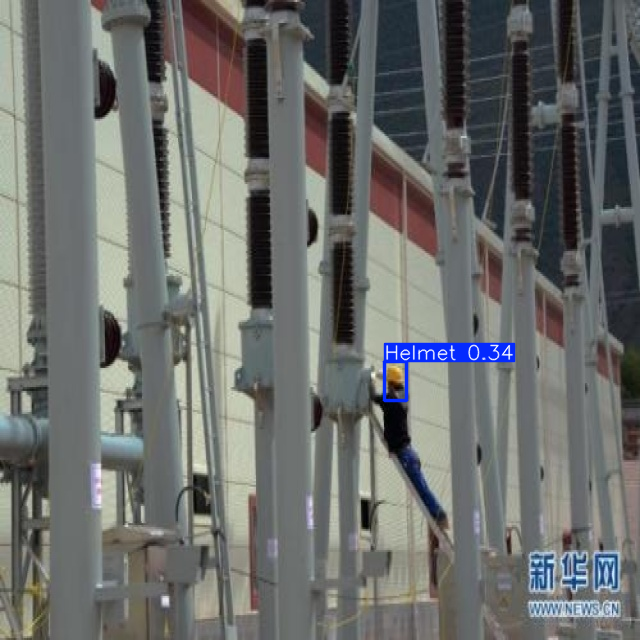


Imagem: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\005833.jpg

image 1/1 C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\005833.jpg: 640x640 4 Helmets, 8.7ms
Speed: 1.6ms preprocess, 8.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


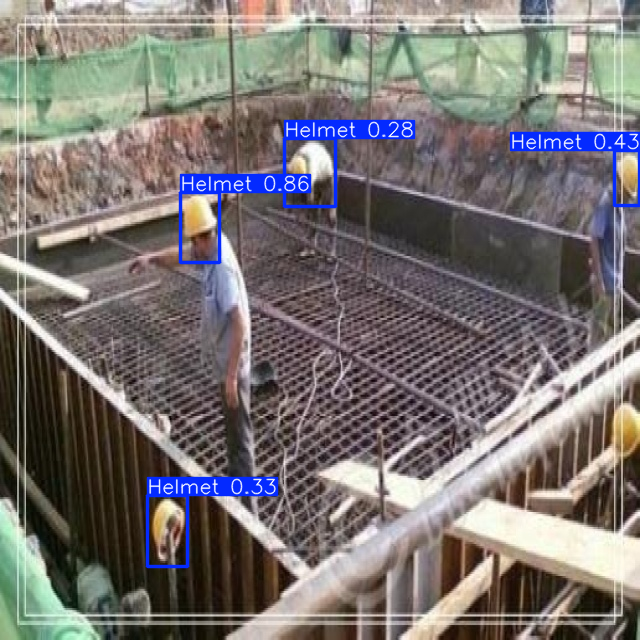


Imagem: C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\002899.jpg

image 1/1 C:\Users\Pedro\.cache\kagglehub\datasets\muhammetzahitaydn\hardhat-vest-dataset-v3\versions\2\images\test\002899.jpg: 640x640 3 Helmets, 1 Head, 8.8ms
Speed: 1.5ms preprocess, 8.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


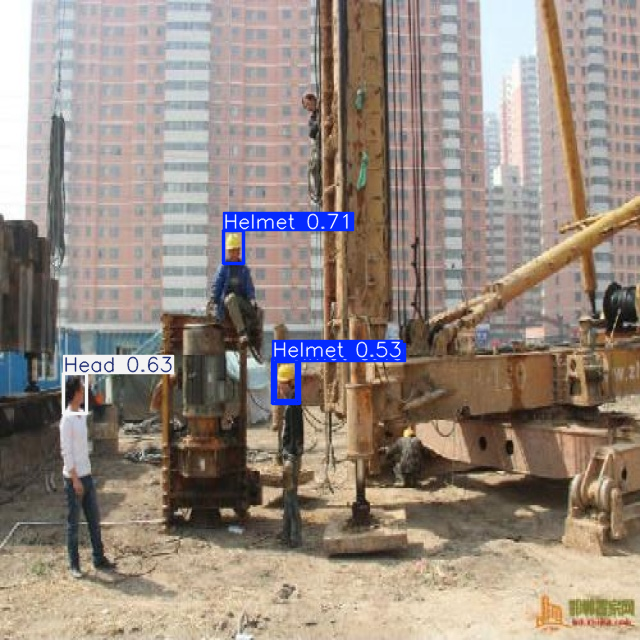

In [50]:
# Célula 7 - Rodar inferência em algumas imagens de teste e visualizar
from IPython.display import display
from PIL import Image
import random

# Caminho para imagens de teste
test_images_dir = IMAGES_DIR / "test"
test_images = list(test_images_dir.glob("*.jpg"))

print("Total de imagens de teste:", len(test_images))

if test_images:
    # escolhe algumas aleatórias
    sample_paths = random.sample(test_images, min(4, len(test_images)))
    for img_path in sample_paths:
        print("\nImagem:", img_path)
        results = model(img_path)  # usa melhor checkpoint por padrão (last)
        for r in results:
            im_array = r.plot()  # numpy array (BGR)
            im = Image.fromarray(im_array[..., ::-1])  # converte para RGB
            display(im)
else:
    print("Nenhuma imagem de teste encontrada em:", test_images_dir)